# Penerapan Machine Learning untuk Klasifikasi Kegagalan Mesin Berdasarkan Kondisi Operasional

**Konteks Proyek:**
Proyek ini menerapkan *Supervised Learning* (Klasifikasi Biner) untuk mengidentifikasi status kegagalan mesin (`Machine failure`). Objek yang dimodelkan adalah *Milling Machine* (Mesin Frais).

**Informasi Dataset:**
Dataset yang digunakan adalah **AI4I 2020 Predictive Maintenance Dataset**. Dataset ini merupakan **data sintetis** yang dimodelkan secara matematis untuk merepresentasikan kondisi operasional historis mesin frais (seperti suhu, kecepatan putaran, torsi, dan keausan alat).

**Keterkaitan SDG:**
Proyek ini berkontribusi pada **SDG 9 – Industry, Innovation and Infrastructure (Target 9.5)** dengan mendemonstrasikan bagaimana teknologi *Machine Learning* dapat dimanfaatkan untuk mengolah data operasional industri dan mendukung inovasi teknologi.

Import Library & Load Data

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import joblib

# Pengaturan visualisasi
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Memuat dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
df = pd.read_csv(url)

print("Dataset AI4I 2020 (Milling Machine) berhasil dibaca!")
display(df.head(3))

Dataset AI4I 2020 (Milling Machine) berhasil dibaca!


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0


Pemeriksaan & Distribusi Kelas

Jumlah Missing Value: 0


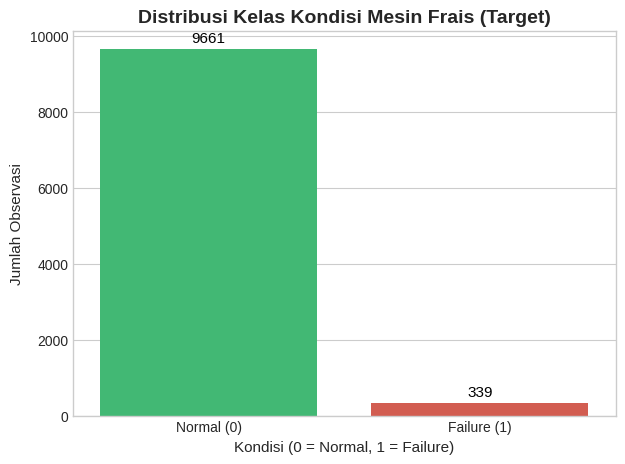

CATATAN EVALUASI:
Distribusi data menunjukkan ketidakseimbangan kelas (Class Imbalance) yang signifikan.
Data kegagalan (Failure) jauh lebih sedikit dibandingkan data Normal. Oleh karena itu, performa model tidak cukup hanya dievaluasi menggunakan Accuracy, melainkan harus memperhatikan nilai Recall dan F1-Score untuk kelas Failure.


In [21]:
# Memastikan tidak ada missing value
print(f"Jumlah Missing Value: {df.isnull().sum().sum()}")

# Visualisasi Distribusi Target (Class Imbalance)
plt.figure(figsize=(7, 5))
# Menambahkan parameter hue dan legend=False untuk mencegah FutureWarning seaborn
ax = sns.countplot(x='Machine failure', hue='Machine failure', data=df, palette=['#2ecc71', '#e74c3c'], legend=False)

plt.title('Distribusi Kelas Kondisi Mesin Frais (Target)', fontsize=14, fontweight='bold')
plt.xlabel('Kondisi (0 = Normal, 1 = Failure)', fontsize=11)
plt.ylabel('Jumlah Observasi', fontsize=11)
plt.xticks([0, 1], ['Normal (0)', 'Failure (1)'])

# Menambahkan angka di atas batang grafik
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

print("CATATAN EVALUASI:")
print("Distribusi data menunjukkan ketidakseimbangan kelas (Class Imbalance) yang signifikan.")
print("Data kegagalan (Failure) jauh lebih sedikit dibandingkan data Normal. Oleh karena itu, performa model tidak cukup hanya dievaluasi menggunakan Accuracy, melainkan harus memperhatikan nilai Recall dan F1-Score untuk kelas Failure.")

Preprocessing: Cleansing, Encoding, Split, & Scaling

In [22]:
# A. Menghapus Identifier & Fitur Data Leakage (Indikator Mode Kegagalan)
kolom_dihapus = ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
df_clean = df.drop(columns=kolom_dihapus)

# B. One-Hot Encoding untuk kolom 'Type' (Kualitas Produk L, M, H)
df_encoded = pd.get_dummies(df_clean, columns=['Type'], drop_first=True, dtype=int)

# C. Pemisahan Fitur (X) dan Target (y)
X = df_encoded.drop(columns=['Machine failure'])
y = df_encoded['Machine failure']

# D. Train-Test Split (80:20) dengan Stratify (karena class imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# E. Standardisasi Fitur (Feature Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Jumlah Data Latih (X_train): {X_train.shape[0]} baris")
print(f"Jumlah Data Uji (X_test)   : {X_test.shape[0]} baris")
print("Preprocessing dan Scaling selesai!")

Jumlah Data Latih (X_train): 8000 baris
Jumlah Data Uji (X_test)   : 2000 baris
Preprocessing dan Scaling selesai!


Training & Evaluasi Model

In [23]:
# Inisialisasi Model
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

predictions = {}
results_list = []

print("--- Memulai Proses Training & Evaluasi Model ---")
for name, model in models.items():
    # 1. Melatih model
    model.fit(X_train_scaled, y_train)

    # 2. Prediksi data uji
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred

    # 3. Hitung Metrik Evaluasi
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results_list.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})
    print(f"Model [{name}] berhasil dievaluasi!")

# Konversi ke DataFrame agar rapi seperti tabel
df_results = pd.DataFrame(results_list).sort_values(by='Recall', ascending=False).reset_index(drop=True)
print("\n=== HASIL PERBANDINGAN MODEL MACHINE LEARNING ===")
display(df_results)

--- Memulai Proses Training & Evaluasi Model ---
Model [Logistic Regression] berhasil dievaluasi!
Model [Random Forest] berhasil dievaluasi!

=== HASIL PERBANDINGAN MODEL MACHINE LEARNING ===


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.9815,0.878049,0.529412,0.660550
1,Logistic Regression,0.9675,0.636364,0.102941,0.177215


Confusion Matrix Model Terbaik

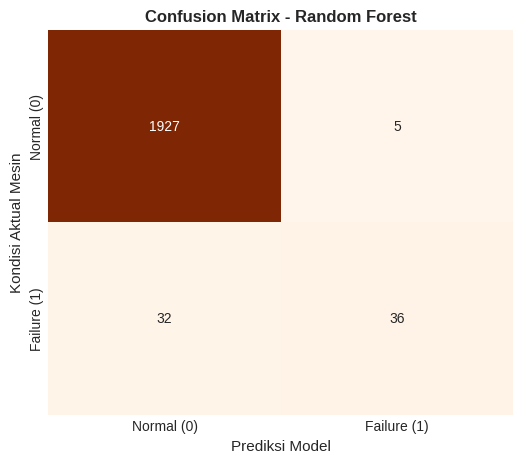

Catatan: Fokus evaluasi adalah meminimalisir False Negative (Aktual Failure namun diprediksi Normal).


In [24]:
# Mengambil Random Forest sebagai model terbaik dalam mendeteksi Failure (Recall tertinggi)
best_model_name = 'Random Forest'
best_pred = predictions[best_model_name]

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Normal (0)', 'Failure (1)'],
            yticklabels=['Normal (0)', 'Failure (1)'])
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=12, fontweight='bold')
plt.xlabel('Prediksi Model', fontsize=11)
plt.ylabel('Kondisi Aktual Mesin', fontsize=11)
plt.show()

print("Catatan: Fokus evaluasi adalah meminimalisir False Negative (Aktual Failure namun diprediksi Normal).")

Tahap Analisis Lanjutan: Simulasi Prediksi Data

In [25]:
# Simulasi prediksi menggunakan sampel data historis yang belum pernah dilihat model (dari X_test)
best_model = models['Random Forest']

# Mengambil 1 sampel acak dari data uji yang secara aktual memiliki label failure (1)
sample_mesin = X_test[y_test == 1].iloc[[0]]
sample_mesin_scaled = scaler.transform(sample_mesin)

# Melakukan prediksi status mesin
prediksi_hasil = best_model.predict(sample_mesin_scaled)[0]
probabilitas = best_model.predict_proba(sample_mesin_scaled)[0]

print("=== HASIL SIMULASI PREDIKSI KONDISI OPERASIONAL ===")
print("Input Data Operasional (Fitur):")
display(sample_mesin)

print(f"\\nPrediksi Label Target : {prediksi_hasil}")
if prediksi_hasil == 1:
    print(f"HASIL KLASIFIKASI: MESIN DIPREDIKSI MENGALAMI FAILURE")
    print(f"Tingkat Keyakinan Model: {probabilitas[1] * 100:.2f}%")
else:
    print(f"HASIL KLASIFIKASI: MESIN DIPREDIKSI NORMAL")
    print(f"Tingkat Keyakinan Model: {probabilitas[0] * 100:.2f}%")

=== HASIL SIMULASI PREDIKSI KONDISI OPERASIONAL ===
Input Data Operasional (Fitur):


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_L,Type_M
4851,303.7,312.1,1363,51.8,90,1,0


\nPrediksi Label Target : 0
HASIL KLASIFIKASI: MESIN DIPREDIKSI NORMAL
Tingkat Keyakinan Model: 81.00%


Tahap Deployment: Export Model

In [26]:
# Tahap ini merupakan persiapan konsep deployment.
# Menyimpan model terbaik, scaler, dan daftar fitur ke dalam format .pkl
# File ini nantinya dapat digunakan untuk pengembangan sistem prediksi (misal: backend aplikasi)
import os

# Membuat folder models jika belum ada
os.makedirs('models', exist_ok=True)

joblib.dump(best_model, 'models/milling_machine_rf_model.pkl')
joblib.dump(scaler, 'models/milling_scaler.pkl')
joblib.dump(X.columns.tolist(), 'models/feature_columns.pkl')

print("Konsep persiapan deployment selesai dilakukan.")
print("File Model Random Forest, Scaler, dan Daftar Fitur telah disimpan ke dalam format .pkl.")

Konsep persiapan deployment selesai dilakukan.
File Model Random Forest, Scaler, dan Daftar Fitur telah disimpan ke dalam format .pkl.


# Kesimpulan

Berdasarkan eksperimen Machine Learning yang telah dilakukan, dapat ditarik kesimpulan sebagai berikut:

1. **Pemodelan Klasifikasi:** Proyek ini berhasil menerapkan algoritma *Machine Learning* untuk melakukan klasifikasi biner terhadap kondisi operasional simulasi mesin frais dengan target `Machine failure`.
2. **Karakteristik Data:** Terdapat *class imbalance* yang tajam pada dataset, di mana kejadian *failure* (3,4%) jauh lebih sedikit dibandingkan kondisi normal (96,6%). Hal ini menuntut penggunaan metrik *Recall* dan *F1-Score* dalam evaluasi model.
3. **Performa Algoritma:** Kedua algoritma (Logistic Regression dan Random Forest) berhasil dilatih. Berdasarkan hasil aktual, **Random Forest** menunjukkan performa yang lebih baik dalam mengidentifikasi kelas *failure* (ditandai dengan nilai *Recall* dan *F1-Score* yang lebih tinggi dibandingkan Logistic Regression).
4. **Analisis Kesalahan:** Melalui *Confusion Matrix*, masih teridentifikasi adanya kasus *False Negative* (kondisi aktual gagal, namun diprediksi normal). Hal ini mengindikasikan bahwa model masih dapat dioptimalkan di masa mendatang, misalnya dengan teknik penanganan *class imbalance* (seperti `class_weight` atau SMOTE).
5. **Keterkaitan SDG 9:** Eksperimen ini berkontribusi terhadap pencapaian **SDG 9 Target 9.5**, dengan mendemonstrasikan bagaimana analitik data industri dan pemodelan *Machine Learning* dapat dimanfaatkan sebagai dasar inovasi teknologi di sektor manufaktur.